# Besoin client 2 — Version améliorée
## Prédiction d'une classe d'âge des arbres

Ce notebook propose une version améliorée du besoin client 2 avec :
- une meilleure préparation des données,
- de nouvelles variables dérivées,
- une gestion des valeurs manquantes par imputation,
- plusieurs modèles de classification,
- une validation croisée stratifiée,
- une optimisation des hyperparamètres avec `GridSearchCV`,
- la sauvegarde du meilleur pipeline pour le script final.


In [1]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

RANDOM_STATE = 42
plt.rcParams["figure.figsize"] = (10, 6)


## 1. Chargement des données

In [2]:
DATA_PATH = "Data_Arbre_Cleaned.csv"
df = pd.read_csv(DATA_PATH)

print("Shape :", df.shape)
display(df.head())
display(df.info())


Shape : (9551, 19)


,X,Y,src_geo,clc_quartier,clc_secteur,id_arbre,haut_tot,haut_tronc,tronc_diam,fk_arb_etat,fk_stadedev,fk_situation,dte_plantation,age_estim,clc_nbr_diag,dte_abattage,nomfrancais,feuillage,remarquable
0,1.720058e+06,8.295025e+06,Orthophoto,Quartier saint-jean,Accueil de loisirs kergomard,1,16.0,4.0,148,En place,Adulte,Groupe,NaN,50,0.0,NaN,Tiltom,Feuillu,Non
1,1.719483e+06,8.295265e+06,Orthophoto,Quartier du vermandois,Ancienne ecole david et maigret,1,5.0,2.0,49,En place,Jeune,Isolé,NaN,20,0.0,NaN,Amelam,Feuillu,Non
2,1.722294e+06,8.295055e+06,Orthophoto,Quartier remicourt,Auberge de jeunesse,1,25.0,2.0,250,Supprimé,Adulte,Alignement,NaN,50,1.0,NaN,Popnigita,Feuillu,Non
3,1.718429e+06,8.295551e+06,Orthophoto,Quartier du vermandois,Avenue archimède,1,7.0,0.0,80,En place,Jeune,Alignement,NaN,15,NaN,NaN,Fagsylfas,Feuillu,Non
4,1.722092e+06,8.294788e+06,Orthophoto,Quartier remicourt,Avenue aristide briand,1,5.0,2.0,25,En place,Jeune,Alignement,NaN,10,0.0,NaN,Amelam,Feuillu,Non


<class 'pandas.DataFrame'>
RangeIndex: 9551 entries, 0 to 9550
Data columns (total 19 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   X               9551 non-null   float64
 1   Y               9551 non-null   float64
 2   src_geo         9228 non-null   str    
 3   clc_quartier    9551 non-null   str    
 4   clc_secteur     9551 non-null   str    
 5   id_arbre        9551 non-null   str    
 6   haut_tot        9551 non-null   float64
 7   haut_tronc      9551 non-null   float64
 8   tronc_diam      9551 non-null   int64  
 9   fk_arb_etat     9551 non-null   str    
 10  fk_stadedev     9544 non-null   str    
 11  fk_situation    9551 non-null   str    
 12  dte_plantation  563 non-null    str    
 13  age_estim       9551 non-null   int64  
 14  clc_nbr_diag    8049 non-null   float64
 15  dte_abattage    753 non-null    str    
 16  nomfrancais     9551 non-null   str    
 17  feuillage       9551 non-null   str    
 18 

None

## 2. Sélection des variables et création de la cible

Le besoin client 2 porte sur la prédiction de l'âge.  
Pour pouvoir utiliser des métriques de classification comme l'accuracy, on transforme `age_estim` en **classes d'âge** :
- `Jeune`
- `Moyen`
- `Vieux`

Tu peux ajuster les seuils si besoin.


In [3]:
# Seuils des classes d'âge
bins = [-np.inf, 20, 50, np.inf]
labels = ["Jeune", "Moyen", "Vieux"]

# Variables de départ
base_features = [
    "haut_tot", "haut_tronc", "tronc_diam", "clc_nbr_diag",
    "clc_quartier", "clc_secteur", "fk_arb_etat", "fk_stadedev",
    "fk_situation", "nomfrancais", "feuillage", "remarquable"
]

df_model = df[base_features + ["age_estim"]].copy()
df_model = df_model.dropna(subset=["age_estim"])

df_model["classe_age"] = pd.cut(df_model["age_estim"], bins=bins, labels=labels)

display(df_model["classe_age"].value_counts())
display(df_model["classe_age"].value_counts(normalize=True).round(3))


classe_age
Moyen    5375
Jeune    3532
Vieux     644
Name: count, dtype: int64

classe_age
Moyen    0.563
Jeune    0.370
Vieux    0.067
Name: proportion, dtype: float64

## 3. Feature engineering

On crée quelques variables dérivées simples qui peuvent améliorer les performances :
- rapport entre hauteur de tronc et hauteur totale,
- rapport entre diamètre et hauteur totale,
- indicateur binaire pour les arbres remarquables.


In [4]:
# Sécurisation pour éviter les divisions par zéro
df_model["haut_tot_safe"] = df_model["haut_tot"].replace(0, np.nan)

df_model["ratio_tronc_haut"] = df_model["haut_tronc"] / df_model["haut_tot_safe"]
df_model["ratio_diam_haut"] = df_model["tronc_diam"] / df_model["haut_tot_safe"]
df_model["remarquable_bin"] = df_model["remarquable"].map({"Oui": 1, "Non": 0})

# Nettoyage de la variable temporaire
df_model = df_model.drop(columns=["haut_tot_safe"])

display(df_model.head())


,haut_tot,haut_tronc,tronc_diam,clc_nbr_diag,clc_quartier,clc_secteur,fk_arb_etat,fk_stadedev,fk_situation,nomfrancais,feuillage,remarquable,age_estim,classe_age,ratio_tronc_haut,ratio_diam_haut,remarquable_bin
0,16.0,4.0,148,0.0,Quartier saint-jean,Accueil de loisirs kergomard,En place,Adulte,Groupe,Tiltom,Feuillu,Non,50,Moyen,0.25,9.250000,0
1,5.0,2.0,49,0.0,Quartier du vermandois,Ancienne ecole david et maigret,En place,Jeune,Isolé,Amelam,Feuillu,Non,20,Jeune,0.40,9.800000,0
2,25.0,2.0,250,1.0,Quartier remicourt,Auberge de jeunesse,Supprimé,Adulte,Alignement,Popnigita,Feuillu,Non,50,Moyen,0.08,10.000000,0
3,7.0,0.0,80,NaN,Quartier du vermandois,Avenue archimède,En place,Jeune,Alignement,Fagsylfas,Feuillu,Non,15,Jeune,0.00,11.428571,0
4,5.0,2.0,25,0.0,Quartier remicourt,Avenue aristide briand,En place,Jeune,Alignement,Amelam,Feuillu,Non,10,Jeune,0.40,5.000000,0


## 4. Séparation X / y

In [5]:
X = df_model.drop(columns=["age_estim", "classe_age"])
y = df_model["classe_age"]

numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()

print("Variables numériques :", numeric_features)
print("Variables catégorielles :", categorical_features)


Variables numériques : ['haut_tot', 'haut_tronc', 'tronc_diam', 'clc_nbr_diag', 'ratio_tronc_haut', 'ratio_diam_haut', 'remarquable_bin']
Variables catégorielles : ['clc_quartier', 'clc_secteur', 'fk_arb_etat', 'fk_stadedev', 'fk_situation', 'nomfrancais', 'feuillage', 'remarquable']


## 5. Train / test split

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train :", X_train.shape, y_train.shape)
print("Test  :", X_test.shape, y_test.shape)


Train : (7640, 15) (7640,)
Test  : (1911, 15) (1911,)


## 6. Prétraitement

- imputation médiane pour les variables numériques,
- standardisation,
- imputation de la modalité la plus fréquente pour les catégorielles,
- one-hot encoding.


In [7]:
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features)
])


## 7. Comparaison de plusieurs modèles par validation croisée

In [8]:
models = {
    "LogisticRegression": LogisticRegression(max_iter=2000, class_weight="balanced", random_state=RANDOM_STATE),
    "RandomForest": RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE),
    "GradientBoosting": GradientBoostingClassifier(random_state=RANDOM_STATE)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

cv_results = []

for name, model in models.items():
    pipe = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("classifier", model)
    ])
    scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring="accuracy", n_jobs=-1)
    cv_results.append({
        "model": name,
        "cv_accuracy_mean": scores.mean(),
        "cv_accuracy_std": scores.std()
    })

cv_results = pd.DataFrame(cv_results).sort_values("cv_accuracy_mean", ascending=False)
display(cv_results)


,model,cv_accuracy_mean,cv_accuracy_std
1,RandomForest,0.962435,0.006353
2,GradientBoosting,0.944241,0.004485
0,LogisticRegression,0.939267,0.003108


## 8. Optimisation du meilleur candidat avec GridSearchCV

On optimise ici un **Random Forest**, souvent performant sur les données tabulaires.


In [9]:
rf_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(class_weight="balanced", random_state=RANDOM_STATE))
])

param_grid = {
    "classifier__n_estimators": [200, 300],
    "classifier__max_depth": [None, 10, 20],
    "classifier__min_samples_split": [2, 5, 10],
    "classifier__min_samples_leaf": [1, 2, 4],
    "classifier__max_features": ["sqrt", "log2"]
}

grid = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="accuracy",
    n_jobs=-1,
    verbose=1
)

grid.fit(X_train, y_train)

print("Meilleurs paramètres :")
print(grid.best_params_)
print("Meilleure accuracy CV :", round(grid.best_score_, 4))


Fitting 5 folds for each of 108 candidates, totalling 540 fits
Meilleurs paramètres :
{'classifier__max_depth': None, 'classifier__max_features': 'log2', 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 5, 'classifier__n_estimators': 300}
Meilleure accuracy CV : 0.9645


## 9. Évaluation finale sur le jeu de test

In [10]:
best_model = grid.best_estimator_
y_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average="weighted", zero_division=0)
recall = recall_score(y_test, y_pred, average="weighted", zero_division=0)
f1 = f1_score(y_test, y_pred, average="weighted", zero_division=0)

print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-score  : {f1:.4f}")

print("\nClassification report :")
print(classification_report(y_test, y_pred, zero_division=0))


Accuracy  : 0.9759
Precision : 0.9762
Recall    : 0.9759
F1-score  : 0.9759

Classification report :
              precision    recall  f1-score   support

       Jeune       0.99      0.97      0.98       707
       Moyen       0.97      0.99      0.98      1075
       Vieux       0.94      0.91      0.93       129

    accuracy                           0.98      1911
   macro avg       0.97      0.96      0.96      1911
weighted avg       0.98      0.98      0.98      1911



## 10. Matrice de confusion

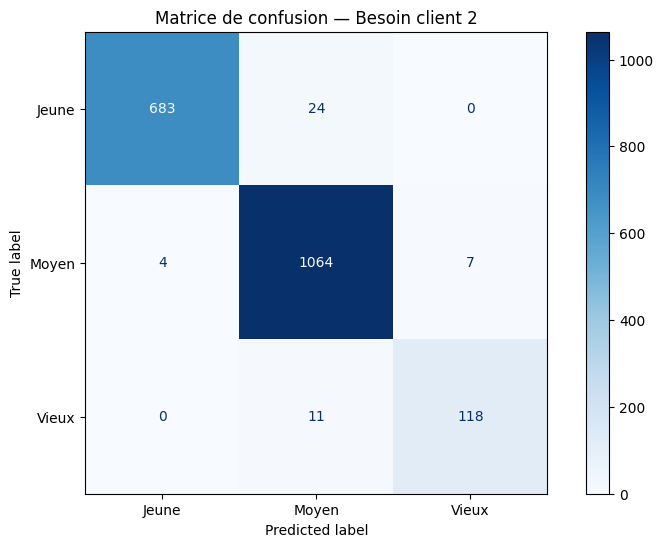

In [11]:
cm = confusion_matrix(y_test, y_pred, labels=best_model.classes_)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=best_model.classes_)
disp.plot(cmap="Blues")
plt.title("Matrice de confusion — Besoin client 2")
plt.show()


## 11. Importance des variables

On affiche les variables les plus importantes du Random Forest.


,feature,importance
2,num__tronc_diam,0.115833
0,num__haut_tot,0.088723
300,cat__fk_stadedev_Jeune,0.079737
1,num__haut_tronc,0.065627
299,cat__fk_stadedev_Adulte,0.062761
5,num__ratio_diam_haut,0.052228
4,num__ratio_tronc_haut,0.042213
122,cat__clc_secteur_Parc des champs-elysées,0.028544
3,num__clc_nbr_diag,0.024430
13,cat__clc_quartier_Quartier du vermandois,0.022755


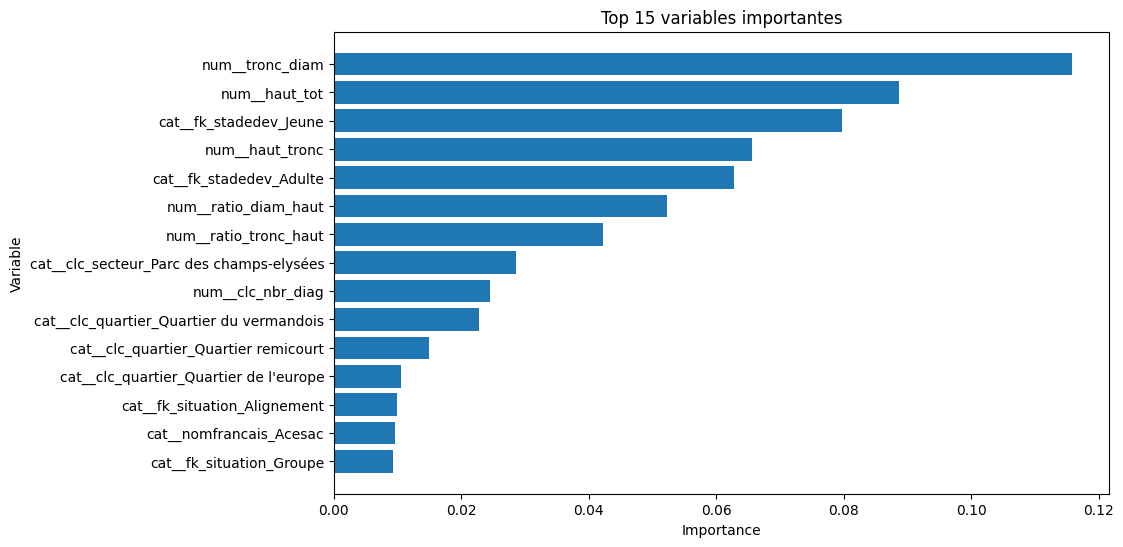

In [12]:
# Récupération des noms de features après preprocessing
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
importances = best_model.named_steps["classifier"].feature_importances_

importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": importances
}).sort_values("importance", ascending=False)

display(importance_df.head(20))

top_n = 15
top_features = importance_df.head(top_n).sort_values("importance")
plt.barh(top_features["feature"], top_features["importance"])
plt.title("Top 15 variables importantes")
plt.xlabel("Importance")
plt.ylabel("Variable")
plt.show()


## 12. Sauvegarde du meilleur pipeline

On sauvegarde directement le pipeline complet (prétraitement + modèle), ce qui simplifie énormément le script final.


In [13]:
os.makedirs("models", exist_ok=True)

with open("models/model_age_classification_pipeline.pkl", "wb") as f:
    pickle.dump(best_model, f)

print("Pipeline sauvegardé dans models/model_age_classification_pipeline.pkl")


Pipeline sauvegardé dans models/model_age_classification_pipeline.pkl


## 13. Exemple de rechargement et de prédiction

In [14]:
with open("models/model_age_classification_pipeline.pkl", "rb") as f:
    loaded_model = pickle.load(f)

sample = X_test.iloc[[0]].copy()
pred_sample = loaded_model.predict(sample)[0]
proba_sample = loaded_model.predict_proba(sample)[0]

print("Exemple d'entrée :")
display(sample)

print("Classe prédite :", pred_sample)
print("Probabilités par classe :")
for cls, proba in zip(loaded_model.classes_, proba_sample):
    print(f"  {cls}: {proba:.4f}")


Exemple d'entrée :


,haut_tot,haut_tronc,tronc_diam,clc_nbr_diag,clc_quartier,clc_secteur,fk_arb_etat,fk_stadedev,fk_situation,nomfrancais,feuillage,remarquable,ratio_tronc_haut,ratio_diam_haut,remarquable_bin
9308,24.0,4.0,200,1.0,Quartier de l'europe,Rue laplace,Supprimé,Adulte,Groupe,Popeurrob,Feuillu,Non,0.166667,8.333333,0


Classe prédite : Moyen
Probabilités par classe :
  Jeune: 0.0092
  Moyen: 0.7935
  Vieux: 0.1974
